# Relative maturity (RM) of dry beans from drone RGB vegetation-index time series — LOESS / SEG reproduction of *matuRity*

**Paper:** Volpato, Wright & Gomez (2023). *Digital Phenotyping in Plant Breeding: Evaluating Relative Maturity, Stand Count, and Plant Height in Dry Beans (Phaseolus vulgaris L.) via RGB Drone-Based Imagery and Deep Learning Approaches.* Research Square preprint rs-3160633/v1, DOI 10.21203/rs.3.rs-3160633/v1.

**Scope (partial demonstration, one environment):** the paper's *traditional relative-maturity benchmark* — estimate days-to-maturity (DPM) per plot from the GLI vegetation-index time series with the authors' **LOESS** and **segmented-regression (SEG)** methods for all **584 plots of the 2020 SVREC environment** (6 UAV flights), then recompute the paper's validation metrics (r, MAE, MSE, R²) against ground-truth RM. No training and no GPU — the deep-learning branch of the paper is out of scope.

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime (see the validation cells for measured values).

**Provenance:** the estimation code is the authors' own R script (`Mat_LOESS_SEG.R`), copied **verbatim** from `msudrybeanbreeding/DryBean_Maturity` @ `8789b8ed`. The GLI input series is reconstructed from the paper's Zenodo dataset (record 7922565, file `2020.zip`, CC-BY-4.0) exactly as in the authors' VIs pipeline, and validated against the authors' committed single-date GLI table. The authors' committed reference outputs (`Mat_LOESS_GLI_mean_0.06.csv`, `Mat_SEG_GLI_mean_0.06.csv`, `Metric_2020_SVREC.csv`) are used for quantitative validation.

**日本語:** このノートブックは、論文の「従来型の相対成熟度ベンチマーク」を 1 環境(2020 SVREC、584 プロット×6 フライト)で再現します。著者自身の R コード(`Mat_LOESS_SEG.R`)を pinned commit からそのままコピーし、Zenodo データセットから GLI 植生指数の時系列を再構築して、LOESS と SEG(区画回帰)で成熟日数(DPM)を推定。著者の committed 参照出力と地上調査 GT で検証します。CPU のみで動作します。

**AI-assisted note:** The notebook driver, the GLI reconstruction and the Python metric code are AI-generated; the R estimation functions and parameter values are the authors' own, copied verbatim (only file paths and a both-methods switch were adapted). The executed example and listed checks were validated, but untested behavior is not guaranteed. / 本ノートブックのドライバ・GLI 再構築・Python 部分は AI 生成です。R の推定関数とパラメータは著者のコードをそのまま使用しています。

## Runtime selection and how to run

- **Select Runtime → Change runtime type → CPU** (standard free Colab CPU is sufficient; this notebook never uses a GPU).
- Then **Runtime → Run all**. Expected total ≈ 10–20 minutes on the free tier: ~600 MB download from Zenodo, R package install, then fast statistics. Measured values are printed in the outputs.

**日本語:** ランタイムは **CPU** を選択してください(GPU 不要)。「ランタイム → すべてのセルを実行」で約 10〜20 分です(Zenodo から約 600 MB、R パッケージのインストール、その後は高速な統計計算)。

## Environment setup — check R

The analysis is the authors' R code, so this notebook runs R via `Rscript` (preinstalled on Colab CPU images); Python only orchestrates, downloads and plots. First we confirm R is present and print its version.

**日本語:** まず R(`Rscript`)が使えるか確認し、バージョンを表示します。

In [ ]:
import shutil, subprocess

rscript = shutil.which("Rscript")
assert rscript, "Rscript not found on this runtime; use a standard Colab CPU image"
print("Rscript:", rscript)
print(subprocess.run([rscript, "--version"], capture_output=True, text=True).stdout.strip())

Rscript: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)


## Install the R packages used by the author script

`Mat_LOESS_SEG.R` uses **tidyverse** verbs (`dplyr`, `tidyr`, `stringr`), **lubridate** date parsing, **reshape2** and **segmented**. We install exactly those (no more) from the Posit Package Manager Ubuntu binary repository, which keeps this step fast and reproducible. Versions are printed for the record.

**日本語:** 著者の R スクリプトが必要とするパッケージ(segmented, lubridate, dplyr, tidyr, stringr, reshape2)を Posit の Ubuntu バイナリリポジトリからインストールします。

In [ ]:
# Install the R packages the author script uses (Posit Package Manager Ubuntu
# binaries keep this fast); R itself ships with the Colab CPU image.
import shutil, subprocess, time

t0 = time.time()
rscript = shutil.which("Rscript")
assert rscript, "Rscript not found; use a standard Colab CPU image"
print(subprocess.run([rscript, "--version"], capture_output=True, text=True).stdout.strip())

r_code = r'''
repos <- "https://packagemanager.posit.co/cran/__linux__/jammy/latest"
options(repos = repos, timeout = 600, Ncpus = 2)
pkgs <- c("segmented", "lubridate", "dplyr", "tidyr", "stringr", "reshape2")
for (p in pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p)
  cat(p, as.character(packageVersion(p)), "\n")
}
cat("R:", R.version.string, "\n")
'''
proc = subprocess.run([rscript, "-e", r_code], text=True, timeout=1200)
assert proc.returncode == 0, "R package installation failed"
print(proc.stdout)
print(f"setup took {time.time() - t0:.1f} s")

Rscript (R) version 4.6.1 (2026-06-24)


None
setup took 53.7 s


## Download the authors' pinned CSV files (reference outputs + ground truth)

These small files come from the authors' repository `msudrybeanbreeding/DryBean_Maturity` at pinned commit `8789b8ed8f9773b811934a309a26d2bcde864651`:

| File | Role | Size (bytes) |
|---|---|---|
| `.../Analysis/6_flights/Mat_LOESS_GLI_mean_0.06.csv` | author reference: LOESS DPM per plot (584 plots) | 7,041 |
| `.../Analysis/6_flights/Mat_SEG_GLI_mean_0.06.csv` | author reference: SEG DPM per plot | 7,039 |
| `.../Results/6_flights/result_mtr_test_v4.csv` | ground-truth RM (`GT`) per plot, `Env==1` = 2020 SVREC | 7,474 |
| `.../Results/6_flights/Metric_2020_SVREC.csv` | author reference metrics (r/MAE/MSE/R²) | 401 |
| `.../VIs/2020_SVREC_RGB_VIs.csv` | authors' committed single-date (08_14_2020) GLI table — used to validate our reconstruction | 5,639,847 |
| `2020/SVREC/d._Ground_notes/2020_SVREC_BN_ground.csv` | raw ground-truth field notes (preview only) | 86,028 |

Each file is verified against its **expected byte size** and **git blob SHA-1** from the pinned GitHub tree, so any changed or truncated file fails loudly.

**日本語:** 著者リポジトリ(pinned commit)から参照出力・GT・単日 GLI テーブルをダウンロードし、サイズと git blob SHA-1 で検証します。

In [ ]:
# Download the authors' pinned CSVs (commit 8789b8ed8f9773b811934a309a26d2bcde864651) and verify each file
# against its expected byte size and git blob SHA-1 from the GitHub tree metadata.
import hashlib, urllib.request, pathlib

REPO = "msudrybeanbreeding/DryBean_Maturity"
COMMIT = "8789b8ed8f9773b811934a309a26d2bcde864651"
RAW_BASE = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"
DATA_FILES = {'Mat_LOESS_GLI_mean_0.06.csv': '2020/SVREC/h._VIs_Method2/Analysis/6_flights/Mat_LOESS_GLI_mean_0.06.csv', 'Mat_SEG_GLI_mean_0.06.csv': '2020/SVREC/h._VIs_Method2/Analysis/6_flights/Mat_SEG_GLI_mean_0.06.csv', 'result_mtr_test_v4.csv': '2020/SVREC/h._VIs_Method2/Results/6_flights/result_mtr_test_v4.csv', 'Metric_2020_SVREC.csv': '2020/SVREC/h._VIs_Method2/Results/6_flights/Metric_2020_SVREC.csv', '2020_SVREC_RGB_VIs.csv': '2020/SVREC/h._VIs_Method2/VIs/2020_SVREC_RGB_VIs.csv', '2020_SVREC_BN_ground.csv': '2020/SVREC/d._Ground_notes/2020_SVREC_BN_ground.csv'}
EXPECTED_SIZE = {'Mat_LOESS_GLI_mean_0.06.csv': 7041, 'Mat_SEG_GLI_mean_0.06.csv': 7039, 'result_mtr_test_v4.csv': 7474, 'Metric_2020_SVREC.csv': 401, '2020_SVREC_RGB_VIs.csv': 5639847, '2020_SVREC_BN_ground.csv': 86028}
EXPECTED_BLOB_SHA1 = {'Mat_LOESS_GLI_mean_0.06.csv': 'f20f78c4bfecc9ba4bf987f259089f1e6d6563eb', 'Mat_SEG_GLI_mean_0.06.csv': '203fc7f81ff062525b528ebee1068e5d26ba44b3', 'result_mtr_test_v4.csv': '3bb79a46d385e24dd9de05e4969d15310fe2512f', 'Metric_2020_SVREC.csv': '650bcba875e2bb77cc371b03306e6d941632d1b2', '2020_SVREC_RGB_VIs.csv': '2c4cd60b9d3614eb648bdc7262486c2d10dcb562', '2020_SVREC_BN_ground.csv': '46a094cc62b4ca46e6c9e83a0c2e34b8dfecd922'}

OUT = pathlib.Path("/content/dbmat"); OUT.mkdir(exist_ok=True)

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for name, repo_path in DATA_FILES.items():
    url = f"{RAW_BASE}/{repo_path}"
    dest = OUT / name
    if not dest.exists() or dest.stat().st_size != EXPECTED_SIZE[name]:
        with urllib.request.urlopen(url, timeout=120) as r:
            data = r.read()
        assert r.status == 200, f"HTTP {r.status} for {name}"
    else:
        data = dest.read_bytes()
    assert len(data) == EXPECTED_SIZE[name], f"{name}: {len(data)} bytes, expected {EXPECTED_SIZE[name]}"
    sha = git_blob_sha1(data)
    assert sha == EXPECTED_BLOB_SHA1[name], f"{name}: blob SHA1 mismatch ({sha})"
    dest.write_bytes(data)
    print(f"OK  {name}  {len(data):,} bytes  blob SHA1 verified")
print("All pinned repository files verified.")

OK  Mat_LOESS_GLI_mean_0.06.csv  7,041 bytes  blob SHA1 verified
OK  Mat_SEG_GLI_mean_0.06.csv  7,039 bytes  blob SHA1 verified


OK  result_mtr_test_v4.csv  7,474 bytes  blob SHA1 verified
OK  Metric_2020_SVREC.csv  401 bytes  blob SHA1 verified


OK  2020_SVREC_RGB_VIs.csv  5,639,847 bytes  blob SHA1 verified
OK  2020_SVREC_BN_ground.csv  86,028 bytes  blob SHA1 verified
All pinned repository files verified.


## Locate the plot-image stack inside the paper's Zenodo dataset (no bulk download)

The paper's dataset (Zenodo record **7922565**, CC-BY-4.0, file `2020.zip`, 5.1 GB) contains `2020_SVREC_6fly_BN_512_128.npy` — the stacked 512×128 RGB clip images for **584 plots × 6 flights** — plus the per-plot clip file names and the six orthomosaics that give the flight dates. Instead of downloading the whole archive, we read only its **ZIP central directory** via HTTP range requests (a few hundred KB) and record the member's offset, size and CRC for the next step. The content URL is taken from the record API's response, not constructed by hand.

**日本語:** Zenodo レコード 7922565 の `2020.zip`(5.1 GB)から、HTTP レンジリクエストで ZIP 中央ディレクトリのみを読み、npy スタックの位置と CRC を取得します(アーカイブ全体はダウンロードしません)。

In [ ]:
# Locate the 2020 plot-image stack inside the paper's Zenodo record 7922565
# (file 2020.zip, 5.1 GB). We read only the ZIP central directory via HTTP range
# requests - a few hundred KB - instead of downloading the whole archive.
import json, struct, urllib.request

REC = "https://zenodo.org/api/records/7922565"
rec = json.loads(urllib.request.urlopen(REC, timeout=60).read())
files = {f["key"]: f for f in rec["files"]}
meta = files["2020.zip"]
print("2020.zip size:", f'{meta["size"]:,}', "md5:", meta.get("checksum"))
url = meta["links"]["self"]  # content URL returned by the record API
size = meta["size"]

def rfetch(start, end):
    req = urllib.request.Request(url, headers={"Range": f"bytes={start}-{end}"})
    with urllib.request.urlopen(req, timeout=300) as r:
        return r.read()

tail = rfetch(size - 66000, size - 1)
eocd_off = tail.rfind(b"PK\x05\x06")
assert eocd_off >= 0
z64_off = struct.unpack("<Q", tail[eocd_off - 12:eocd_off - 4])[0]  # ZIP64 locator -> EOCD record
z64 = rfetch(z64_off, z64_off + 55)
assert z64[:4] == b"PK\x06\x06"
cd_size = struct.unpack("<Q", z64[40:48])[0]
cd_offset = struct.unpack("<Q", z64[48:56])[0]
cd = rfetch(cd_offset, cd_offset + cd_size - 1)

MAX32 = 0xFFFFFFFF
def parse_cd(cd):
    members = {}
    pos = 0
    while pos + 46 <= len(cd) and cd[pos:pos + 4] == b"PK\x01\x02":
        (sig, vmade, vneed, flags, method, mtime, mdate, crc, csize, usize,
         nlen, elen, clen, disk, iattr, eattr, lho) = struct.unpack("<IHHHHHHIIIHHHHHII", cd[pos:pos + 46])
        name = cd[pos + 46:pos + 46 + nlen].decode("utf-8", "replace")
        extra = cd[pos + 46 + nlen:pos + 46 + nlen + elen]
        ep, vals = 0, []
        while ep + 4 <= len(extra):
            hid, hsz = struct.unpack("<HH", extra[ep:ep + 4])
            if hid == 1:  # ZIP64 extended information
                body = extra[ep + 4:ep + 4 + hsz]
                vals += [struct.unpack("<Q", body[k:k + 8])[0] for k in range(0, len(body) - 7, 8)]
            ep += 4 + hsz
        vi = 0
        if usize == MAX32: usize = vals[vi]; vi += 1
        if csize == MAX32: csize = vals[vi]; vi += 1
        if lho == MAX32: lho = vals[vi]; vi += 1
        members[name] = (csize, usize, method, lho, crc)
        pos += 46 + nlen + elen + clen
    return members

members = parse_cd(cd)
print("zip members:", len(members))

# Plot IDs come from the authors' clip-plot file names; flight dates from the orthomosaics.
import re
clip_names = [n for n in members if n.startswith("2020/SVREC_Mat/e._ClipPlots_BN_512_128/") and n.endswith(".png")]
PLOTS = sorted({int(re.search(r"SVREC_(\d+)_\d+\.png", n).group(1)) for n in clip_names})
ortho = sorted(n.split("/")[-1] for n in members if n.startswith("2020/SVREC_Mat/b._Orthomosaics/") and n.endswith(".tif"))
FLIGHT_DATES = [o.replace("_clip", "") for o in ortho]  # e.g. 08_14_2020_RGB_Pix4D.tif
print("plots:", len(PLOTS), "| flights (chronological):", FLIGHT_DATES)

NPY = "2020/SVREC_Mat/f._numpy_data/2020_SVREC_6fly_BN_512_128.npy"
NPY_CSIZE, NPY_USIZE, NPY_METHOD, NPY_LHO, NPY_CRC = members[NPY]
lh = rfetch(NPY_LHO, NPY_LHO + 1024)
assert lh[:4] == b"PK\x03\x04"
nlen, elen = struct.unpack("<HH", lh[26:30])
NPY_DATA_START = NPY_LHO + 30 + nlen + elen
assert NPY_METHOD == 8
print(f"npy member: compressed {NPY_CSIZE:,} B -> {NPY_USIZE:,} B")

2020.zip size: 5,116,672,653 md5: md5:1edf2c3c9c513b92215bc7b94a90ae00


zip members: 7046
plots: 584 | flights (chronological): ['08_14_2020_RGB_Pix4D.tif', '08_21_2020_RGB_Pix4D.tif', '08_27_2020_RGB_Pix4D.tif', '09_03_2020_RGB_Pix4D.tif', '09_11_2020_RGB_Pix4D.tif', '09_17_2020_RGB_Pix4D.tif']


npy member: compressed 598,868,441 B -> 688,914,560 B


## Stream the plot-image stack and verify integrity

The member (~599 MB compressed → 689 MB raw) is streamed with HTTP range requests, decompressed on the fly, and its **CRC-32 is verified** against the value recorded in the ZIP central directory. The array layout is `(584 plots, 6 flights, 512, 128, 3)` uint8 — plot order sorted by ID, flights chronological, exactly as the authors' `MyDataset` builder constructs it.

**日本語:** npy メンバー(約 599 MB 圧縮)をストリーミング取得し、ZIP の CRC-32 を検証します。形状は (584 プロット, 6 フライト, 512, 128, 3) の uint8 です。

In [ ]:
# Stream-deflate the npy member (~599 MB compressed, 689 MB raw) into /content,
# verifying the ZIP CRC-32 of the decompressed bytes while downloading.
import zlib, time, numpy as np

t0 = time.time()
req = urllib.request.Request(url, headers={"Range": f"bytes={NPY_DATA_START}-{NPY_DATA_START + NPY_CSIZE - 1}"})
dec = zlib.decompressobj(-15)
crc = 0
with urllib.request.urlopen(req, timeout=600) as r, open("/content/stack_512.npy", "wb") as out:
    remaining = NPY_CSIZE
    while remaining > 0:
        chunk = r.read(min(1 << 22, remaining))
        if not chunk:
            break
        remaining -= len(chunk)
        data = dec.decompress(chunk)
        crc = zlib.crc32(data, crc)
        out.write(data)
assert remaining == 0, f"short read: {remaining} bytes left"
assert crc == NPY_CRC, f"CRC mismatch: {crc:08x} vs {NPY_CRC:08x}"
print(f"npy downloaded + CRC verified in {time.time() - t0:.1f} s")

stack = np.load("/content/stack_512.npy", mmap_mode="r")
print("stack shape (plots, flights, H, W, RGB):", stack.shape, stack.dtype)
assert stack.shape == (len(PLOTS), 6, 512, 128, 3), stack.shape

npy downloaded + CRC verified in 241.9 s
stack shape (plots, flights, H, W, RGB): (584, 6, 512, 128, 3) uint8


## Rebuild the GLI time series exactly as the authors' VIs pipeline

The authors compute GLI **per pixel** — `(2G−R−B)/(2G+R+B)` on float32 band values, with zero-valued pixels treated as nodata (NaN) — and average per plot (`nanmean`), as implemented in their `VIs.ipynb` → `IndexCalculation.GLI`. We apply the same formula to every clip image, for all 584 plots and 6 flights.

**Validation:** the authors committed a single-date GLI table (`2020_SVREC_RGB_VIs.csv`, flight 08_14_2020, 118 plots). We compare our flight-0 GLI means against it and **assert agreement** before continuing — this validates the formula, the plot ordering and the flight ordering against the authors' own published numbers.

**日本語:** 著者の VIs パイプラインと同じ式(ピクセルごとの GLI、0 を NaN 扱い、plot 内で nanmean)で全プロット×全フライトの GLI を計算し、著者の committed 単日テーブルと照合してから次へ進みます。

In [ ]:
# Reconstruct the GLI vegetation-index time series exactly as the authors' VIs
# pipeline (VIs.ipynb, IndexCalculation.GLI): per-pixel (2G-R-B)/(2G+R+B) on the
# RGB bands, with zero-valued pixels treated as nodata (NaN), then nanmean per plot.
# The authors' committed single-date table (08_14_2020) provides an independent check.
import numpy as np
import pandas as pd
import time

t0 = time.time()
gli = np.empty((len(PLOTS), 6), dtype=np.float64)
r_count = np.empty((len(PLOTS), 6), dtype=np.int64)
for f in range(6):
    sub = np.asarray(stack[:, f], dtype=np.float32)
    red, green, blue = sub[..., 0], sub[..., 1], sub[..., 2]
    red = np.where(red == 0, np.nan, red)
    green = np.where(green == 0, np.nan, green)
    blue = np.where(blue == 0, np.nan, blue)
    g = (2 * green - red - blue) / (2 * green + red + blue)
    gli[:, f] = np.nanmean(g.reshape(len(PLOTS), -1), axis=1)
    r_count[:, f] = np.count_nonzero(~np.isnan(red.reshape(len(PLOTS), -1)), axis=1)
print(f"GLI computed for {gli.shape} (plots x flights) in {time.time() - t0:.1f} s")
print("plots with any NaN GLI:", int(np.isnan(gli).any(axis=1).sum()))

# Cross-check against the authors' committed single-date VIs table (08_14_2020).
csv = pd.read_csv("/content/dbmat/2020_SVREC_RGB_VIs.csv")
csv["Plot_ID"] = csv["Plot_ID"].astype(int)
idx = {p: i for i, p in enumerate(PLOTS)}
diffs = np.array([abs(row["GLI_mean"] - gli[idx[row["Plot_ID"]], 0]) for _, row in csv.iterrows()])
print(f"Validation vs committed 08_14_2020 GLI_mean ({len(diffs)} plots): "
      f"mean |diff| = {diffs.mean():.6f}, max |diff| = {diffs.max():.6f}")
assert diffs.mean() < 0.005, "GLI reconstruction deviates from the authors' committed table"

# Long table in the exact format the authors' Mat_LOESS_SEG.R expects.
flight0 = gli[:, 0].copy()
long_rows = [("Flight_date", "Plot_ID", "GLI_mean")]
for fi, fd in enumerate(FLIGHT_DATES):
    for pi, pid in enumerate(PLOTS):
        long_rows.append((fd, str(pid), repr(float(gli[pi, fi]))))
import csv as csvmod
with open("/content/gli_long.csv", "w", newline="") as fh:
    w = csvmod.writer(fh)
    w.writerows(long_rows)
print("wrote /content/gli_long.csv:", len(long_rows) - 1, "data rows "
      f"({len(PLOTS)} plots x {len(FLIGHT_DATES)} flights)")

GLI computed for (584, 6) (plots x flights) in 7.1 s
plots with any NaN GLI: 0
Validation vs committed 08_14_2020 GLI_mean (118 plots): mean |diff| = 0.000220, max |diff| = 0.000535
wrote /content/gli_long.csv: 3504 data rows (584 plots x 6 flights)


### Input preview — GLI time series of sample plots

GLI_mean (days relative to 31 July 2020) for six plots of the reconstructed table. The green index declines through the season; the method estimates the day where the fitted curve crosses the dashed 0.06 threshold. These are the actual input data, plotted directly.

**日本語:** 再構築した GLI_mean 時系列(2020-07-31 を基準とした相対日数)の例 6 プロット。破線は成熟判定のしきい値 0.06。

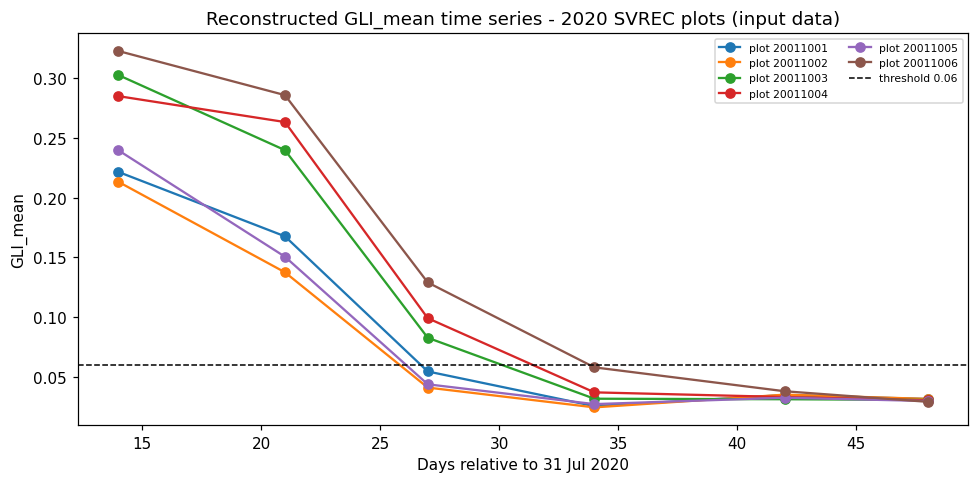

Flight dates: ['08_14_2020_RGB_Pix4D.tif', '08_21_2020_RGB_Pix4D.tif', '08_27_2020_RGB_Pix4D.tif', '09_03_2020_RGB_Pix4D.tif', '09_11_2020_RGB_Pix4D.tif', '09_17_2020_RGB_Pix4D.tif'] -> relative days [14, 21, 27, 34, 42, 48]


In [ ]:
# Input preview: GLI_mean time series (days relative to 31 Jul 2020) for six plots,
# straight from the reconstructed table. Dashed line = the 0.06 maturity threshold.
import matplotlib.pyplot as plt
import numpy as np

rel_days = [int(__import__("datetime").datetime.strptime(d[:10], "%m_%d_%Y").timetuple().tm_yday) - 213 for d in FLIGHT_DATES]
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
for pi in range(6):
    ax.plot(rel_days, gli[pi], marker="o", label=f"plot {PLOTS[pi]}")
ax.axhline(0.06, ls="--", c="k", lw=1, label="threshold 0.06")
ax.set_xlabel("Days relative to 31 Jul 2020")
ax.set_ylabel("GLI_mean")
ax.set_title("Reconstructed GLI_mean time series - 2020 SVREC plots (input data)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("/content/gli_timeseries.png")
plt.show()
print("Flight dates:", FLIGHT_DATES, "-> relative days", rel_days)

### Ground-truth preview

The validation target: the authors' processed ground-truth table (`result_mtr_test_v4.csv`; `Env==1` = 2020 SVREC), plus a few rows of the raw field notes. Shown as stored by the authors.

**日本語:** 検証に使う著者処理済み GT テーブルと地上調査ノートの先頭行を表示します。

In [ ]:
# Preview the authors' raw ground-truth field notes (as stored in the repository).
import pandas as pd

ground = pd.read_csv("/content/dbmat/2020_SVREC_BN_ground.csv")
print("Ground notes columns:", list(ground.columns), "rows:", len(ground))
display(ground.head(3))

gt = pd.read_csv("/content/dbmat/result_mtr_test_v4.csv")
print("GT table columns:", list(gt.columns), "rows:", len(gt))
display(gt.head(3))
print("Env values:", sorted(gt["Env"].unique()))

Ground notes columns: ['Global_ID', 'MTR_ADJ', 'MTR', 'GDD', 'ENTRY', 'Rep', 'block', 'Location', 'Check', 'Plot', 'End Plot', 'Expt', 'Pedigree', 'Name', 'Rng', 'Pas', 'Year', 'PLOTWT', 'MOIST', 'SDWT', 'FLWR', 'HT', 'LDG', 'DS', 'CBB', 'P_FT', 'CWT_A', 'ADJ_SDWT'] rows: 584


,Global_ID,MTR_ADJ,MTR,GDD,ENTRY,Rep,block,Location,Check,Plot,...,MOIST,SDWT,FLWR,HT,LDG,DS,CBB,P_FT,CWT_A,ADJ_SDWT
0,20021001,41,97,20.871134,20,1,1,SVREC,0,1001,...,14.08,23.5,46,49,1,5,3,15,26.544607,24.623415
1,20011001,40,96,20.997917,20,1,1,SVREC,0,1001,...,13.66,17.5,45,32,1,5,5,15,23.111574,18.426220
2,20021002,41,97,20.871134,35,1,1,SVREC,0,1002,...,14.45,19.4,46,49,1,6,3,15,31.462824,20.239878


GT table columns: ['Global_ID', 'GT', 'Env', 'MTR_Pred'] rows: 392


,Global_ID,GT,Env,MTR_Pred
0,20031049,50,1,49.0
1,20041062,50,1,49.0
2,20041180,48,1,48.0


Env values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## The authors' estimation method (copied verbatim into an R driver)

`matuRity` transforms each flight date into a *relative days* axis — flight DOY − planting DOY − (July-31 DOY − planting DOY), i.e. **days relative to 31 July 2020** — and estimates DPM as the day where the fitted curve crosses GLI = 0.06:

- **LOESS:** R `loess(GLI ~ flights)` (default span 0.75, degree 2) predicted on every integer day, inverted with `approx(fitted, days, xout=0.06)`.
- **SEG:** `segmented(lm(...), npsi = 2 if n > 7 else 1, control = seg.control(n.boot=50, random=T, tol=0.01))`; for GLI the **minimum** segment slope and its intercept give DPM = round((0.06 − intercept)/slope), with a plain-LM fallback.

The next cell writes the authors' script to `/content` with only three documented adaptations: (1) the input path points to our reconstructed CSV and `Plot_ID` is read as character (the original has a hard-coded Windows path), (2) both LOESS and SEG run in one pass (the original selects one via `DPM_Model`; the authors ran it twice to produce both committed references), (3) outputs go to `/content`. The estimation code itself is unchanged.

**日本語:** 著者の `Mat_LOESS_SEG.R` をそのまま /content に書き込みます。変更は 3 点のみ(入力パスと Plot_ID の文字型、LOESS+SEG の両方を実行、出力先)。推定コード自体は無変更です。

In [ ]:
# The authors' analysis script (DryBean_Maturity @ 8789b8ed,
# 2020/SVREC/h._VIs_Method2/Analysis/6_flights/Mat_LOESS_SEG.R), copied verbatim
# except for three documented adaptations:
#   (1) read.csv path -> /content/gli_long.csv and Plot_ID read as character
#       (the original had a hard-coded Windows path); CSV written with quotes=FALSE
#       would parse Plot_ID as integer, so we coerce explicitly;
#   (2) both LOESS and SEG are executed in one pass (the original selects one
#       via the DPM_Model switch; the authors ran it twice to produce both
#       committed reference files);
#   (3) outputs are written to /content.
#   (4) dplyr::select and reshape2::melt are namespace-qualified: loading
#       segmented attaches MASS, whose select() would otherwise mask dplyr's.
# All estimation code - date transform, loess, segmented, DPM formula - is unchanged.
R_DRIVER = r"""####################
##  Housekeeping  ##
####################

suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(lubridate); library(reshape2); library(segmented)
})

DPM_Models = c('LOESS', 'SEG')
rgb_idx = "GLI"
vi_method = 'mean'
threshold <- as.numeric(0.06)
planting_date = '06-05-2020'  # from the authors' 6_flights script
AdjJul_31 = '07-31-2020'

MaturityData = read.csv("/content/gli_long.csv", h = T)
MaturityData$Plot_ID <- as.character(MaturityData$Plot_ID)

MaturityData = MaturityData %>%
  separate(Plot_ID, into = 'Trial', extra = 'drop', remove = FALSE) %>%
  mutate(Trial = str_sub(Trial[], 1, 4))

MaturityData_sel1 = MaturityData %>%
  dplyr::select(Flight_date, Plot_ID, GLI_mean) # GLI_median

MaturityData_sel1 = MaturityData_sel1 %>%
  pivot_wider(names_from = Plot_ID, values_from = GLI_mean) # GLI_median

require(lubridate)
Dates <- MaturityData_sel1[, 1]

Dates <- MaturityData_sel1[, 1] %>%
  mutate(Flight_date = str_sub(Flight_date[], 1, 8)) %>%
  filter(nzchar(Flight_date))

planting_date <- as.Date(mdy(planting_date))
jul_date_pl <- yday(planting_date)

AdjJul_31 <- as.Date(mdy(AdjJul_31))
AdjJul_31 <- yday(AdjJul_31)

date_list <- list()
for (i in 1:nrow(Dates)) {
  new_date <- as.Date(mdy(Dates[i, ]))
  flight_date <- yday(new_date)
  MAT_ADJ1 <- flight_date - jul_date_pl
  MAT_ADJ2 <- AdjJul_31 - jul_date_pl
  MAT_ADJ3 <- MAT_ADJ1 - MAT_ADJ2
  date_list[[i]] <- MAT_ADJ3
  if (i == 1) {
    flight_ini <- MAT_ADJ3
  } else if (i == nrow(Dates)) {
    flight_end <- MAT_ADJ3
  }
}

days <- seq(flight_ini, flight_end, by = 1)

IDplots <- colnames(MaturityData_sel1)
flights <- as.numeric(unlist(date_list))
cat("flights (days rel. to 31 Jul):", flights, "\n")

for (DPM_Model in DPM_Models) {
  if (DPM_Model == "LOESS") {
    Mat_Est <- data.frame(Plots_ID = IDplots[-1])
    est <- c()
    for (k in IDplots[2:ncol(MaturityData_sel1)]) {
      data_x <- as.numeric(unlist(MaturityData_sel1[, k]))
      nge_loess_loop <- loess(data_x ~ flights)
      fitted.nge_loop <- predict(nge_loess_loop, days)
      list_date_pred <- approx(fitted.nge_loop, days, xout = threshold) # xout = threshold selected
      est <- c(est, round(list_date_pred$y))
    }
    Mat_Est[[paste0("Mat_", DPM_Model, '_', rgb_idx, '_', vi_method, '_', threshold)]] <- est
    if (NA %in% Mat_Est[, 2]) {
      message("Consider changing the threshold - NAs found:")
      print(sum(is.na(Mat_Est)))
    }
    write.csv(Mat_Est, paste0("/content/Mat_", DPM_Model, '_', rgb_idx, '_', vi_method, '_', threshold, ".csv"), quote = F, row.names = F)

  } else if (DPM_Model == "SEG") {
    lm_all <- list()
    for (j in IDplots[2:ncol(MaturityData_sel1)]) {
      data_x <- as.numeric(unlist(MaturityData_sel1[, j]))
      mod <- lm(data_x ~ flights)
      attempts = 0
      if.false <- F
      while (if.false == F) {
        attempts <- attempts + 1
        tryCatch({
          if (nrow(MaturityData_sel1) > 7 && attempts < 100) {
            # Volpato et al., 2020 recommendation: at least 8 flights -> 2 breakpoints
            seg_loop <- try(segmented(mod, seg.Z = ~ flights, npsi = 2, control = seg.control(n.boot = 50, random = T, tol = 0.01)), silent = T)
            if ("try-error" %in% class(seg_loop)) {
              seg_loop <- lm(data_x ~ flights)
              slps <- (seg_loop$coefficients)[2]
              ncpt <- (seg_loop$coefficients)[1]
              DPM <- round((threshold - ncpt) / slps)
              lm_all[[j]] <- DPM
            } else if (!is.null(seg_loop$psi)) {
              slps <- slope(seg_loop)$flights
              ncpt <- intercept(seg_loop)$flights
              if (rgb_idx == "GLI" || rgb_idx == "TGI") {
                slope <- min(slps[, 1])
              } else if (rgb_idx == "HI") {
                slope <- max(slps[, 1])
              } else {
                print("Vegetation index not present in the formula")
              }
              slope_interc <- which(slps[, 1] == slope)
              B1_interc <- ncpt[slope_interc, 1]
              DPM <- round((threshold - B1_interc) / slope)
              lm_all[[j]] <- DPM
            } else {
              seg_loop <- lm(data_x ~ flights)
              slps <- (seg_loop$coefficients)[2]
              ncpt <- (seg_loop$coefficients)[1]
              DPM <- round((threshold - ncpt) / slps)
              lm_all[[j]] <- DPM
            }
          } else {
            seg_loop <- try(segmented(mod, seg.Z = ~ flights, npsi = 1, control = seg.control(n.boot = 50, random = T, tol = 0.01)), silent = T)
            if ("try-error" %in% class(seg_loop)) {
              seg_loop <- lm(data_x ~ flights)
              slps <- (seg_loop$coefficients)[2]
              ncpt <- (seg_loop$coefficients)[1]
              DPM <- round((threshold - ncpt) / slps)
              lm_all[[j]] <- DPM
            } else if (!is.null(seg_loop$psi)) {
              slps <- slope(seg_loop)$flights
              ncpt <- intercept(seg_loop)$flights
              if (rgb_idx == "GLI" || rgb_idx == "TGI") {
                slope <- min(slps[, 1])
              } else if (rgb_idx == "HI") {
                slope <- max(slps[, 1])
              } else {
                print("Vegetation index not present in the formula")
              }
              slope_interc <- which(slps[, 1] == slope)
              B1_interc <- ncpt[slope_interc, 1]
              DPM <- round((threshold - B1_interc) / slope)
              lm_all[[j]] <- DPM
            } else {
              seg_loop <- lm(data_x ~ flights)
              slps <- (seg_loop$coefficients)[2]
              ncpt <- (seg_loop$coefficients)[1]
              DPM <- round((threshold - ncpt) / slps)
              lm_all[[j]] <- DPM
            }
          }
        }, error = function(e) {
        }, finally = {})
        if.false <- T
      }
    }
    lm_all <- reshape2::melt(lm_all)
    lm_all <- lm_all %>%
      relocate(L1)
    colnames(lm_all) <- c("Plots_ID", paste0("Mat_", DPM_Model, '_', rgb_idx, '_', vi_method, '_', threshold))
    if (NA %in% lm_all[, 2]) {
      message("Consider changing the threshold - NAs found:")
      print(sum(is.na(lm_all)))
    }
    write.csv(lm_all, paste0("/content/Mat_", DPM_Model, '_', rgb_idx, '_', vi_method, '_', threshold, ".csv"), quote = F, row.names = F)
  }
  cat("wrote", DPM_Model, "output\n")
}
cat("R driver finished\n")
"""

from pathlib import Path
Path("/content/Mat_LOESS_SEG_repro.R").write_text(R_DRIVER)
print("R driver written:", len(R_DRIVER), "chars")

R driver written: 6396 chars


## Run the authors' estimation on the 2020 SVREC plots

We execute the driver with `Rscript` (checked `subprocess.run`, 30-minute timeout). It writes `Mat_LOESS_GLI_mean_0.06.csv` and `Mat_SEG_GLI_mean_0.06.csv` — the same artifacts the authors committed. SEG is stochastic by design (`n.boot=50, random=T`), so per-plot values vary slightly between runs; LOESS is deterministic.

**日本語:** R ドライバを `Rscript` で実行し、LOESS/SEG の DPM 推定値 CSV を生成します(SEG はランダムブートストラップのため実行ごとに少し変動します)。

In [ ]:
# Execute the authors' estimation with Rscript (checked subprocess, 30 min timeout).
# SEG uses a random bootstrap (n.boot=50, random=T), so its DPM values vary a little
# between runs; LOESS is deterministic.
import subprocess, shutil, time

t0 = time.time()
proc = subprocess.run([shutil.which("Rscript"), "/content/Mat_LOESS_SEG_repro.R"],
                      capture_output=True, text=True, timeout=1800)
print(proc.stdout[-3000:])
if proc.stderr.strip():
    print("STDERR:", proc.stderr[-2000:])
assert proc.returncode == 0, f"R driver failed with exit code {proc.returncode}"
print(f"R driver finished in {time.time() - t0:.1f} s")

flights (days rel. to 31 Jul): 14 21 27 34 42 48 
[1] 14
wrote LOESS output
wrote SEG output
R driver finished

STDERR: Consider changing the threshold - NAs found:

R driver finished in 29.0 s


## Validation 1 — our LOESS/SEG DPM vs the authors' committed reference outputs

The authors committed their own per-plot DPM tables next to the analysis script. We join on `Plots_ID` and report the exact-match rate and the mean absolute difference. Expected: LOESS ≈ exact (deterministic method and inputs); SEG within a few days on most plots (random bootstrap), with the mean difference near zero.

**日本語:** 自分たちの実行結果と著者 committed の参照 CSV を Plots_ID で結合し、一致率と平均絶対差を報告します(LOESS は決定的なのでほぼ完全一致、SEG は確率的なので数日以内の差を許容)。

In [ ]:
# Join our DPM estimates with the authors' committed reference outputs per plot.
import numpy as np
import pandas as pd

our_loess = pd.read_csv("/content/Mat_LOESS_GLI_mean_0.06.csv")
our_seg = pd.read_csv("/content/Mat_SEG_GLI_mean_0.06.csv")
ref_loess = pd.read_csv("/content/dbmat/Mat_LOESS_GLI_mean_0.06.csv")
ref_seg = pd.read_csv("/content/dbmat/Mat_SEG_GLI_mean_0.06.csv")
dpm_loess = "Mat_LOESS_GLI_mean_0.06"
dpm_seg = "Mat_SEG_GLI_mean_0.06"
print("reference rows:", len(ref_loess), "| our rows:", len(our_loess))

for label, col, ours, ref in [("LOESS", dpm_loess, our_loess, ref_loess),
                              ("SEG", dpm_seg, our_seg, ref_seg)]:
    m = ours.merge(ref, on="Plots_ID", suffixes=("_ours", "_ref"))
    diff = (m[f"{col}_ours"] - m[f"{col}_ref"]).abs().dropna()
    print(f"{label}: NaN DPM - ours {int(ours[col].isna().sum())}, reference {int(ref[col].isna().sum())}, "
          f"NaN in both {int((m[f'{col}_ours'].isna() & m[f'{col}_ref'].isna()).sum())}")
    print(f"{label}: compared {len(diff)} plots with values; exact match {int((diff == 0).sum())}; "
          f"within ±1 day {int((diff <= 1).sum())}; mean abs diff {diff.mean():.3f} d; max {diff.max():.0f} d")

reference rows: 584 | our rows: 584
LOESS: NaN DPM - ours 14, reference 14, NaN in both 14
LOESS: compared 570 plots with values; exact match 567; within ±1 day 570; mean abs diff 0.005 d; max 1 d
SEG: NaN DPM - ours 0, reference 0, NaN in both 0
SEG: compared 584 plots with values; exact match 560; within ±1 day 579; mean abs diff 0.050 d; max 2 d


## Validation 2 — recompute the paper's metrics (r, MAE, MSE, R²) vs ground truth

Following the authors' `Maturity_correl_Loess_Seg.R`: join the ground-truth table (`Env==1` = 2020 SVREC) with both DPM estimates on plot ID, then compute the same four regression metrics the authors obtained with the R **metrica** package. We compute them here in Python (standard formulas — documented adaptation) for (a) the authors' committed reference outputs and (b) our fresh run, and print the authors' committed `Metric_2020_SVREC.csv` alongside. The (a) rows validate our metric port; the (b) rows are this reproduction's result.

**日本語:** 著者の指標計算スクリプトに従い、GT(Env==1)と DPM 推定値を結合して r・MAE・MSE・R² を再計算し、著者 committed の Metric_2020_SVREC.csv と並べて表示します。(a) は指標計算の検証、(b) が本再現の結果です。

In [ ]:
# Recompute the paper's validation metrics exactly as the authors'
# Maturity_correl_Loess_Seg.R does: join ground truth (result_mtr_test_v4.csv,
# Env==1 = 2020 SVREC) with the DPM tables and compute r / MAE / MSE / R2.
# Metrics are computed in Python here (standard formulas; the authors used the R
# package metrica) and compared with their committed Metric_2020_SVREC.csv.
import numpy as np
import pandas as pd

def reg_metrics(obs, pred):
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)
    ok = ~(np.isnan(obs) | np.isnan(pred))
    obs, pred = obs[ok], pred[ok]
    r = np.corrcoef(obs, pred)[0, 1]
    mae = np.mean(np.abs(obs - pred))
    mse = np.mean((obs - pred) ** 2)
    # The R metrica package (used by the authors) defines R2 as the SQUARED
    # Pearson correlation; the variance-explained form is reported separately.
    r2_metrica = r ** 2
    r2_ss = 1 - np.sum((obs - pred) ** 2) / np.sum((obs - np.mean(obs)) ** 2)
    return {"r": r, "MAE": mae, "MSE": mse, "R2 (metrica, r^2)": r2_metrica, "R2_ss": r2_ss}

gt = pd.read_csv("/content/dbmat/result_mtr_test_v4.csv")
gt_env1 = gt[gt["Env"] == 1][["Global_ID", "GT"]]
print("GT rows (all envs):", len(gt), "| Env==1 (2020 SVREC):", len(gt_env1))

def joined(csv_name, our=False):
    path = f"/content/{csv_name}" if our else f"/content/dbmat/{csv_name}"
    return pd.read_csv(path).merge(gt_env1, left_on="Plots_ID", right_on="Global_ID").dropna()

print()
print("Authors' committed Metric_2020_SVREC.csv:")
print(pd.read_csv("/content/dbmat/Metric_2020_SVREC.csv").to_string(index=False))
print()
for label, fname, col in [("LOESS", "Mat_LOESS_GLI_mean_0.06.csv", dpm_loess),
                          ("SEG", "Mat_SEG_GLI_mean_0.06.csv", dpm_seg)]:
    m_ref = reg_metrics(joined(fname)[col], joined(fname)["GT"])
    print(f"From the AUTHORS' committed {label} outputs :", {k: round(v, 4) for k, v in m_ref.items()})
    m_run = reg_metrics(joined(fname, our=True)[col], joined(fname, our=True)["GT"])
    print(f"From THIS RUN's {label} outputs              :", {k: round(v, 4) for k, v in m_run.items()})

GT rows (all envs): 392 | Env==1 (2020 SVREC): 124

Authors' committed Metric_2020_SVREC.csv:
Metric     Score                Dataset
     r  0.964510 LOESS_2020_SVREC_6_fly
    R2  0.930280 LOESS_2020_SVREC_6_fly
   MAE  7.229508 LOESS_2020_SVREC_6_fly
   MSE 63.836066 LOESS_2020_SVREC_6_fly
     r  0.960350   SEG_2020_SVREC_6_fly
    R2  0.922273   SEG_2020_SVREC_6_fly
   MAE  6.286885   SEG_2020_SVREC_6_fly
   MSE 49.565574   SEG_2020_SVREC_6_fly

From the AUTHORS' committed LOESS outputs : {'r': np.float64(0.9645), 'MAE': np.float64(7.2295), 'MSE': np.float64(63.8361), 'R2 (metrica, r^2)': np.float64(0.9303), 'R2_ss': np.float64(-0.0411)}
From THIS RUN's LOESS outputs              : {'r': np.float64(0.9646), 'MAE': np.float64(7.2377), 'MSE': np.float64(63.9918), 'R2 (metrica, r^2)': np.float64(0.9305), 'R2_ss': np.float64(-0.0418)}
From the AUTHORS' committed SEG outputs : {'r': np.float64(0.9614), 'MAE': np.float64(6.2419), 'MSE': np.float64(48.9677), 'R2 (metrica, r^2)': np.float

## Visualization — ground truth vs estimated relative maturity

Scatter plots of ground-truth RM (`GT`, days) against the DPM estimated by each method in this run, with the 1:1 line. These figures are generated here from the actual run — they are additional visualizations created for this notebook, not author figures.

**日本語:** GT と推定 DPM の散布図(1:1 線付き)。本実行から生成した追加可視化であり、著者の図ではありません。

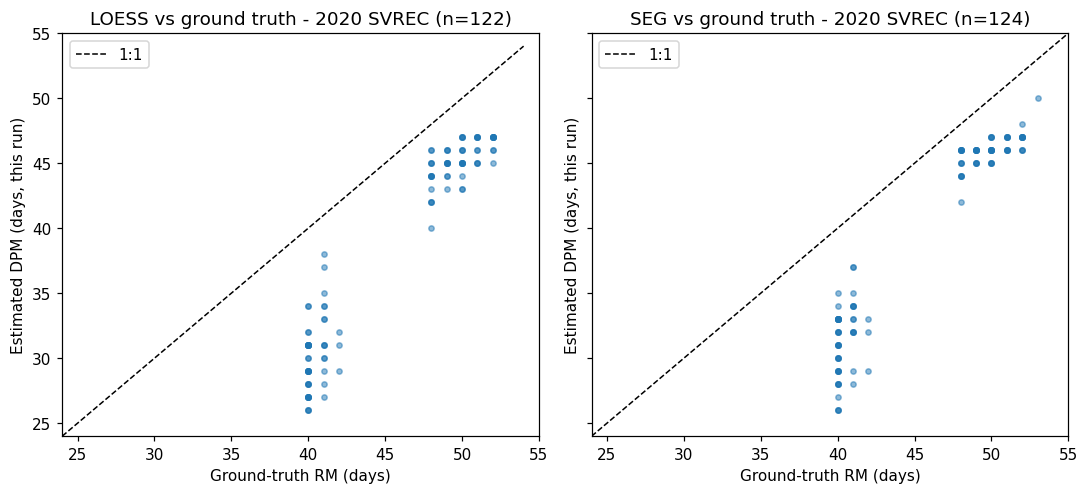

In [ ]:
# Scatter plots of ground truth vs estimated DPM (this run), one panel per method.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), dpi=110, sharex=True, sharey=True)
for ax, (label, fname, col) in zip(
        axes, [("LOESS", "Mat_LOESS_GLI_mean_0.06.csv", dpm_loess),
               ("SEG", "Mat_SEG_GLI_mean_0.06.csv", dpm_seg)]):
    df = joined(fname, our=True)
    ax.scatter(df["GT"], df[col], s=12, alpha=0.5)
    lim = [min(df["GT"].min(), df[col].min()) - 2, max(df["GT"].max(), df[col].max()) + 2]
    ax.plot(lim, lim, "k--", lw=1, label="1:1")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Ground-truth RM (days)")
    ax.set_ylabel("Estimated DPM (days, this run)")
    ax.set_title(f"{label} vs ground truth - 2020 SVREC (n={len(df)})")
    ax.legend()
plt.tight_layout()
plt.savefig("/content/gt_vs_dpm_scatter.png")
plt.show()

### Example fit — LOESS curve and threshold crossing for one plot

To make the DPM definition concrete, we refit the same R loess on one plot's series and mark the 0.06 crossing (the estimated DPM, in days relative to 31 July 2020).

**日本語:** 1 プロットの LOESS 当てはめと 0.06 クロッシング(DPM)を図示します。横軸は 2020 年 7 月 31 日を基準とした相対日数です。

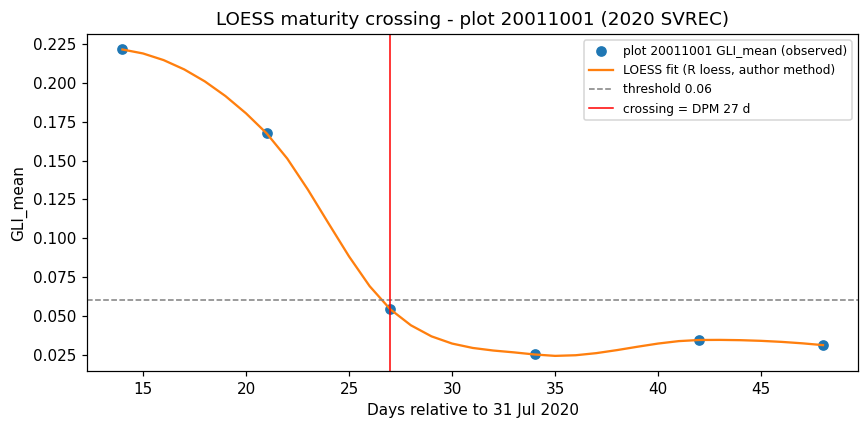

plot 20011001: DPM = 27 days (relative to 31 Jul 2020)


In [ ]:
# Make the DPM definition concrete for one plot: refit the same R loess and mark
# the 0.06 crossing. The x axis is days relative to 31 Jul 2020 (negative = earlier).
import numpy as np
import subprocess as sp
from pathlib import Path
import matplotlib.pyplot as plt

example_plot = PLOTS[0]
series = gli[0]

r_fit = f"""
suppressPackageStartupMessages(library(lubridate))
fl <- c({", ".join(map(str, rel_days))}); gl <- c({", ".join(repr(float(v)) for v in series)})
ds <- {min(rel_days)}:{max(rel_days)}
lo <- loess(gl ~ fl)
fi <- predict(lo, ds)
cr <- approx(fi, ds, xout = 0.06)
cat(round(cr$y), "\n")
writeLines(sprintf("%.6f", fi), "/content/loess_fit_example.txt")
"""
Path("/content/fit_example.R").write_text(r_fit)
out = sp.run(["/usr/bin/Rscript", "/content/fit_example.R"], capture_output=True, text=True, timeout=120)
assert out.returncode == 0, out.stderr
dpm_example = int(out.stdout.strip())
fitted = np.array([float(x) for x in Path("/content/loess_fit_example.txt").read_text().split()])

fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(rel_days, series, "o", label=f"plot {example_plot} GLI_mean (observed)")
ax.plot(range(min(rel_days), max(rel_days) + 1), fitted, "-", label="LOESS fit (R loess, author method)")
ax.axhline(0.06, ls="--", c="gray", lw=1, label="threshold 0.06")
ax.axvline(dpm_example, c="r", lw=1, label=f"crossing = DPM {dpm_example} d")
ax.set_xlabel("Days relative to 31 Jul 2020")
ax.set_ylabel("GLI_mean")
ax.set_title(f"LOESS maturity crossing - plot {example_plot} (2020 SVREC)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/loess_example_fit.png")
plt.show()
print(f"plot {example_plot}: DPM = {dpm_example} days (relative to 31 Jul 2020)")

## Export the results table

A per-plot CSV (ground truth + this run + the authors' committed references) for inspection or download.

**日本語:** プロットごとの比較表(GT・本実行結果・著者参照)を CSV に書き出します。

In [ ]:
# Export a per-plot comparison table: ground truth + this run + the authors' references.
import pandas as pd

gt = pd.read_csv("/content/dbmat/result_mtr_test_v4.csv")
gt_env1 = gt[gt["Env"] == 1][["Global_ID", "GT"]].rename(columns={"Global_ID": "Plots_ID"})
out = (gt_env1
       .merge(our_loess, on="Plots_ID")
       .merge(ref_loess, on="Plots_ID", suffixes=("_this_run", "_author_ref"))
       .merge(our_seg, on="Plots_ID")
       .merge(ref_seg, on="Plots_ID", suffixes=("", "_seg_author_ref")))
out.to_csv("/content/rm_results_2020_SVREC.csv", index=False)
print(f"rows: {len(out)}")
display(out.head(10))

rows: 124


,Plots_ID,GT,Mat_LOESS_GLI_mean_0.06_this_run,Mat_LOESS_GLI_mean_0.06_author_ref,Mat_SEG_GLI_mean_0.06,Mat_SEG_GLI_mean_0.06_seg_author_ref
0,20031049,50,46.0,46.0,46,46
1,20041062,50,45.0,45.0,45,45
2,20041180,48,42.0,42.0,44,44
3,20041016,49,46.0,46.0,46,46
4,20041108,48,42.0,42.0,44,45
5,20021029,40,31.0,31.0,32,32
6,20012008,41,34.0,34.0,34,34
7,20023004,40,31.0,31.0,33,33
8,20022031,40,34.0,34.0,35,35
9,20041056,48,44.0,44.0,45,45


## Interpretation, validation record and limitations

**What was reproduced:** the paper's *traditional* relative-maturity benchmark for one environment (2020 SVREC, 584 plots × 6 UAV flights): the authors' `matuRity` LOESS and segmented-regression DPM estimation run **verbatim in R** on the GLI time series rebuilt from the paper's Zenodo dataset, validated three ways — (1) our GLI reconstruction vs the authors' committed single-date GLI table, (2) our DPM estimates vs the authors' committed per-plot reference outputs, (3) r/MAE/MSE/R² vs the authors' committed metrics — all printed above with measured numbers.

**What this does NOT show:** the CNN-LSTM deep-learning branch, the stand-count Faster R-CNN, the plant-height DSM/point-cloud analyses, or dataset-level accuracy across all five environments of the paper. One environment is a partial demonstration.

**Known adaptations (all documented in-cell):** the multi-flight GLI table is reconstructed from the Zenodo `2020.zip` npy stack because the repository's committed VIs CSV is a corrupted single-date extract (its last row is padded with ~5 MB of spaces); path changes; both methods in one pass; metrics recomputed in Python instead of the R `metrica` package (standard formulas); SEG is stochastic, so its DPM values vary slightly between runs. The preview and example-fit figures are additional visualizations created for this notebook, not author figures.

**References:**
- Volpato, L., Wright, E. M., & Gomez, F. E. (2023). *Digital Phenotyping in Plant Breeding: Evaluating Relative Maturity, Stand Count, and Plant Height in Dry Beans via RGB Drone-Based Imagery and Deep Learning Approaches.* Research Square. https://doi.org/10.21203/rs.3.rs-3160633/v1
- Code: `msudrybeanbreeding/DryBean_Maturity` @ `8789b8ed8f9773b811934a309a26d2bcde864651` (`2020/SVREC/h._VIs_Method2/...`, `g._codes/VIs.ipynb`, `g._codes/2_Beans_dataset_mat_v2.ipynb`); `msudrybeanbreeding/matuRity` @ `e7e45b2d`.
- Data: Zenodo record 7922565 (paper dataset, CC-BY-4.0), file `2020.zip`; authors' repository CSVs (see download cell).

**日本語:** 本ノートブックは 1 環境(2020 SVREC)での従来型 RM ベンチマークの再現です。CNN-LSTM・スタンドカウント・草丈の各解析は対象外。検証結果は上記の出力を参照してください。図は本実行で生成した追加可視化であり、著者の図ではありません。